<a href="https://colab.research.google.com/github/Mistmoonn/laba/blob/main/ml1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Подготовка

In [14]:
import pandas as pd
import numpy as np
from matplotlib import pyplot as plt
from sklearn.linear_model import LogisticRegression, LogisticRegressionCV
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler, RobustScaler, LabelEncoder, OneHotEncoder
from sklearn.pipeline import make_pipeline

In [15]:
data=pd.read_csv('/content/synthetic_customer_churn_100k.csv')
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 9 columns):
 #   Column          Non-Null Count   Dtype  
---  ------          --------------   -----  
 0   CustomerID      100000 non-null  int64  
 1   Age             100000 non-null  int64  
 2   Gender          100000 non-null  object 
 3   Tenure          100000 non-null  int64  
 4   MonthlyCharges  100000 non-null  float64
 5   Contract        100000 non-null  object 
 6   PaymentMethod   100000 non-null  object 
 7   TotalCharges    100000 non-null  float64
 8   Churn           100000 non-null  object 
dtypes: float64(2), int64(3), object(4)
memory usage: 6.9+ MB


In [16]:
num_cols=['CustomerID', 'Age', 'Tenure','MonthlyCharges','TotalCharges' ]
cat_cols=['Gender','Contract','PaymentMethod']
feature_cols= num_cols+cat_cols
target_col='Churn'

In [17]:
data[num_cols].describe()

,CustomerID,Age,Tenure,MonthlyCharges,TotalCharges
count,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000
mean,50000.500000,49.027240,36.527090,79.974933,2926.140256
std,28867.657797,18.177862,20.789552,40.491961,2388.163672
min,1.000000,18.000000,1.000000,10.000000,-118.430000
25%,25000.750000,33.000000,18.000000,44.720000,963.667500
50%,50000.500000,49.000000,37.000000,80.000000,2268.060000
75%,75000.250000,65.000000,54.000000,115.050000,4394.327500
max,100000.000000,80.000000,72.000000,150.000000,10831.460000


In [18]:
data.isna().sum()

,0
CustomerID,0
Age,0
Gender,0
Tenure,0
MonthlyCharges,0
Contract,0
PaymentMethod,0
TotalCharges,0
Churn,0


array([[<Axes: title={'center': 'CustomerID'}>,
        <Axes: title={'center': 'Age'}>],
       [<Axes: title={'center': 'Tenure'}>,
        <Axes: title={'center': 'MonthlyCharges'}>],
       [<Axes: title={'center': 'TotalCharges'}>, <Axes: >]], dtype=object)

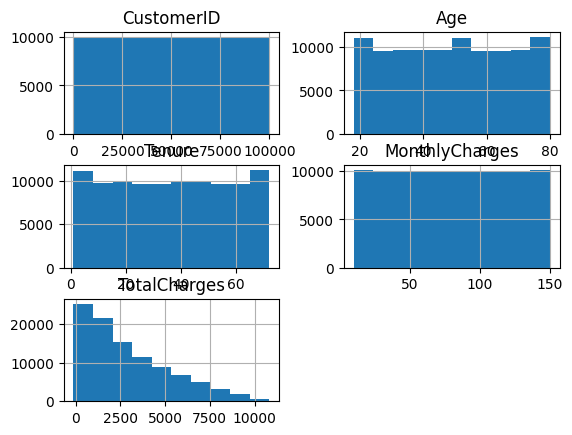

In [19]:
data.hist()

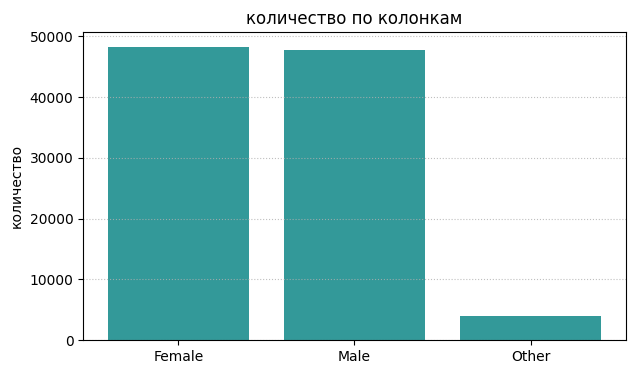

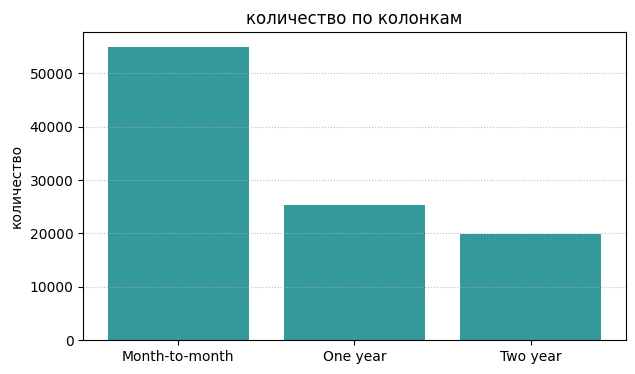

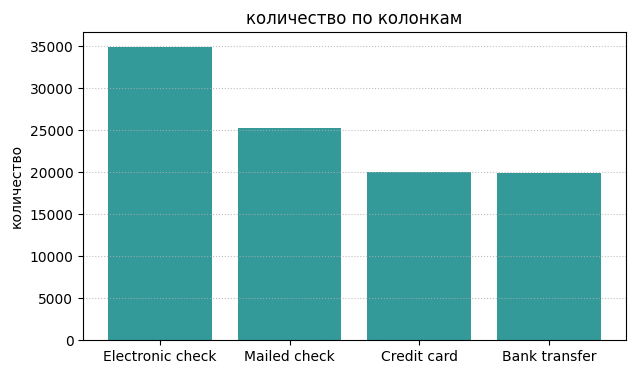

In [20]:
for cols in cat_cols:
  counts=data[cols].value_counts()
  plt.figure(figsize= (7,4))
  plt.bar(counts.index,counts.values,color='teal',alpha=0.8)
  plt.title('количество по колонкам')
  plt.ylabel('количество')
  plt.grid(axis='y',linestyle=':',alpha=0.8 )
  plt.show()

<function matplotlib.pyplot.show(close=None, block=None)>

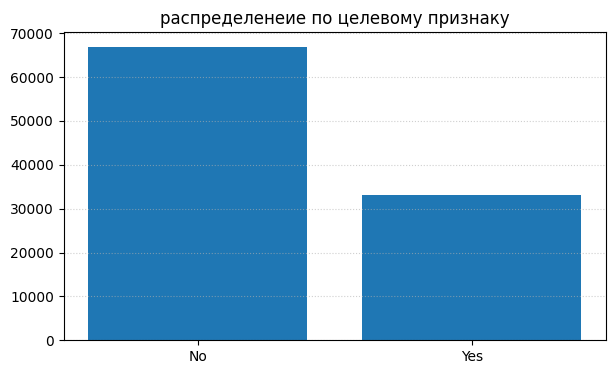

In [21]:
plt.figure(figsize=(7,4))
counts=data['Churn'].value_counts()
plt.bar(counts.index,counts.values)
plt.title('распределенеие по целевому признаку')
plt.grid(axis='y', linestyle=':', alpha=0.6)
plt.show

In [22]:
dummies=pd.get_dummies(data[cat_cols])
X_boost=data.iloc[:,:-1]
y=data[target_col]
X=pd.concat([data[num_cols],dummies],axis=1)

X.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 15 columns):
 #   Column                          Non-Null Count   Dtype  
---  ------                          --------------   -----  
 0   CustomerID                      100000 non-null  int64  
 1   Age                             100000 non-null  int64  
 2   Tenure                          100000 non-null  int64  
 3   MonthlyCharges                  100000 non-null  float64
 4   TotalCharges                    100000 non-null  float64
 5   Gender_Female                   100000 non-null  bool   
 6   Gender_Male                     100000 non-null  bool   
 7   Gender_Other                    100000 non-null  bool   
 8   Contract_Month-to-month         100000 non-null  bool   
 9   Contract_One year               100000 non-null  bool   
 10  Contract_Two year               100000 non-null  bool   
 11  PaymentMethod_Bank transfer     100000 non-null  bool   
 12  PaymentMethod_Cre

In [23]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    shuffle=True
)


scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

model = LogisticRegressionCV(
    Cs=[0.01, 0.1, 1, 10, 50],
    cv=5,
    penalty='l2',
    scoring='roc_auc',
    n_jobs=-1,
    random_state=42,
    max_iter=1000
)

model.fit(X_train_scaled, y_train)


print(f"Лучшее C: {model.C_[0]}")

best_score = model.scores_[model.classes_[1]].mean(axis=0).max()
print(f"Лучший ROC-AUC score: {best_score:.4f}")

Лучшее C: 0.1
Лучший ROC-AUC score: 0.7717


In [24]:
!pip install catboost

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 97.1/97.1 MB 10.7 MB/s eta 0:00:00


In [25]:
from catboost import CatBoostClassifier
from sklearn.metrics import roc_auc_score
boost_X = data.drop(target_col, axis=1)
boost_y = data[target_col]
X_train_b, X_val_b, y_train_b, y_val_b = train_test_split(
    boost_X, boost_y,
    train_size=0.8,
    random_state=42,
    stratify=boost_y
)

cat_boost = CatBoostClassifier(
    cat_features=cat_cols,
    eval_metric='AUC',
    verbose=False
)

cat_boost.fit(X_train_b, y_train_b)

y_val_pred = cat_boost.predict_proba(X_val_b)[:, 1]
cat_score = roc_auc_score(y_val_b, y_val_pred)

print(f"ROC-AUC стандартной модели CatBoost: {cat_score:.4f}")

ROC-AUC стандартной модели CatBoost: 0.8035


In [28]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import roc_auc_score

X_rf = pd.get_dummies(data.drop(columns=[target_col]), drop_first=True)
y_rf = data[target_col]


X_train_rf, X_val_rf, y_train_rf, y_val_rf = train_test_split(
    X_rf, y_rf,
    train_size=0.8,
    random_state=42,
    stratify=y_rf
)


rf_model = RandomForestClassifier(
    n_estimators=100,
    max_depth=10,
    random_state=42,
    n_jobs=-1)

rf_model.fit(X_train_rf, y_train_rf)

# 4. Предсказание вероятностей и расчет ROC-AUC
y_val_pred_rf = rf_model.predict_proba(X_val_rf)[:, 1]
rf_score = roc_auc_score(y_val_rf, y_val_pred_rf)

print(f"ROC-AUC для Random Forest: {rf_score:.4f}")

ROC-AUC для Random Forest: 0.8059
